# **Knowledge distillation**

Compress the continual-learning model into a small student and compare four ways of
training it. The teacher is the replay + LwF ResNet50; the student is a
MobileNetV3-Small + LSTM. Both are trained and tested on the full 20-class set.

- **CE**: the student alone, no teacher (the baseline).
- **CE + KD**: CE plus KL between the student's and teacher's softened logits.
- **CE + Cosine**, CE plus cosine distance between the two 256-d LSTM states.
- **CE + MSE**, CE plus MSE between the two 256-d LSTM states.

## **Connect Colab**

## Computational environment and repository synchronisation

This cell retrieves the specified repository revision and configures the runtime import path, establishing a reproducible implementation environment.

In [1]:
import os, sys, subprocess
from getpass import getpass

REPO   = "silvergjeka22/Unified-Lifelong-Action-Learning"
BRANCH = "real-video"
ROOT   = "/content/ulal"

token = os.environ.get("GITHUB_TOKEN") or getpass("GitHub token: ")
os.environ["GITHUB_TOKEN"] = token

if os.path.isdir(os.path.join(ROOT, ".git")):
    subprocess.run(["git", "-C", ROOT, "fetch", "--depth", "1", "origin", BRANCH], check=True)
    subprocess.run(["git", "-C", ROOT, "reset", "--hard", "FETCH_HEAD"], check=True)
else:
    subprocess.run(["git", "clone", "--depth", "1", "--branch", BRANCH,
                    "https://" + token + "@github.com/" + REPO + ".git", ROOT], check=True)

if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

## Dataset-access credentials

Environment variables are configured for authenticated dataset access. Credential values are placeholders and must be supplied only in a secure private environment.

In [2]:
os.environ["KAGGLE_USERNAME"] = "colab"
os.environ["KAGGLE_KEY"]      = "KEY"

## **Download DATASET**

## Dataset acquisition and runtime initialisation

The bootstrap routine initialises the project environment and retrieves the data required by the distillation experiment.

In [3]:
from src.bootstrap import setup
setup(drive=True, dataset=True)

Mounted at /content/drive
Drive mounted.
Using Colab cache for faster access to the 'ucf101-action-recognition' dataset.
ULAL_DATASET_ROOT = /kaggle/input/ucf101-action-recognition/
ULAL_OUTPUT_ROOT  = /kaggle/working/ucf101-processed/
ULAL_DATA_ROOT     = /content/UCF101
ULAL_DRIVE_PROJECT = /content/drive/MyDrive/apai
Setup complete — no config.py edit, no kernel restart.


## Dependencies and stochastic control

Shared dependencies are loaded and the configured random seed is fixed, reducing uncontrolled variability during training.

In [4]:
# imports
%run /content/ulal/src/imports.py
set_seed(cfg.SEED)

ULAL_ROOT : /content/ulal
Device    : cuda
Classes   : base=10 task1=5 task2=5


42

## **Preprocess data**

Group-disjoint clips for all three tasks

## Group-disjoint task partitions

This cell builds source-video group splits for all three tasks, preventing correlated clips from crossing data partitions.

In [5]:
base_split  = build_group_split(cfg.SELECTED_CLASSES, train_groups=18, val_groups=3)
task1_split = build_group_split(cfg.TASK_1,           train_groups=18, val_groups=3)
task2_split = build_group_split(cfg.TASK_2,           train_groups=18, val_groups=3)

## Base-task preprocessing

The base-task partition is materialised for student training under the group-disjoint protocol and the prescribed sample limit.

In [8]:
# BASE (max_samples caps TRAIN clips/class; None = full data, val/test untouched)
preprocess_group_split(base_split, cfg.SELECTED_CLASSES, output_root=cfg.BASE_ROOT, max_samples=None)


--- Preprocessing (group-disjoint) ---
To  : /content/UCF101/grouped_base
Classes: 10 | Train limit: Full

Processing split: train



Processing split: val



Processing split: test



Done. Clips ready at: /content/UCF101/grouped_base


## Task 1 preprocessing

The first incremental-task clips are prepared using the same data-limited preprocessing protocol.

In [9]:
# TASK 1 (same TRAIN-only cap via cfg.MAX_SAMPLES)
preprocess_group_split(task1_split, cfg.TASK_1, output_root=cfg.TASK1_ROOT, max_samples=None)


--- Preprocessing (group-disjoint) ---
To  : /content/UCF101/grouped_task1
Classes: 5 | Train limit: Full

Processing split: train



Processing split: val



Processing split: test



Done. Clips ready at: /content/UCF101/grouped_task1


## Task 2 preprocessing

This cell prepares the second incremental-task clips consistently with the preceding tasks.

In [10]:
# TASK 2 (same TRAIN-only cap via cfg.MAX_SAMPLES)
preprocess_group_split(task2_split, cfg.TASK_2, output_root=cfg.TASK2_ROOT, max_samples=None)


--- Preprocessing (group-disjoint) ---
To  : /content/UCF101/grouped_task2
Classes: 5 | Train limit: Full

Processing split: train



Processing split: val



Processing split: test



Done. Clips ready at: /content/UCF101/grouped_task2


## Global label encoding

A fixed cumulative class order and integer mapping are defined for the full 20-class student problem.

In [11]:
ALL_CLASSES_LIST = cfg.SELECTED_CLASSES + cfg.TASK_1 + cfg.TASK_2
class_to_idx     = {cls_name: i for i, cls_name in enumerate(ALL_CLASSES_LIST)}
print(f"{len(ALL_CLASSES_LIST)} classes")
print(class_to_idx)

20 classes
{'PlayingTabla': 0, 'PommelHorse': 1, 'JumpingJack': 2, 'PushUps': 3, 'PoleVault': 4, 'HorseRace': 5, 'HighJump': 6, 'Drumming': 7, 'HorseRiding': 8, 'Diving': 9, 'ApplyEyeMakeup': 10, 'ApplyLipstick': 11, 'Archery': 12, 'BabyCrawling': 13, 'BalanceBeam': 14, 'BoxingPunchingBag': 15, 'BoxingSpeedBag': 16, 'BrushingTeeth': 17, 'CliffDiving': 18, 'CricketBowling': 19}


## **Create Loaders**

The student is trained on all 20 classes at once, so the three tasks are concatenated into one train / val / test set.

## Unified student data loaders

The three task-specific partitions are concatenated so that the student is trained and evaluated jointly on the complete 20-class classification problem.

In [12]:
base_train  = UCF101Clips(os.path.join(cfg.BASE_ROOT,  "train"), class_to_idx=class_to_idx)
base_val    = UCF101Clips(os.path.join(cfg.BASE_ROOT,  "val"),   class_to_idx=class_to_idx)
base_test   = UCF101Clips(os.path.join(cfg.BASE_ROOT,  "test"),  class_to_idx=class_to_idx)
task1_train = UCF101Clips(os.path.join(cfg.TASK1_ROOT, "train"), class_to_idx=class_to_idx)
task1_val   = UCF101Clips(os.path.join(cfg.TASK1_ROOT, "val"),   class_to_idx=class_to_idx)
task1_test  = UCF101Clips(os.path.join(cfg.TASK1_ROOT, "test"),  class_to_idx=class_to_idx)
task2_train = UCF101Clips(os.path.join(cfg.TASK2_ROOT, "train"), class_to_idx=class_to_idx)
task2_val   = UCF101Clips(os.path.join(cfg.TASK2_ROOT, "val"),   class_to_idx=class_to_idx)
task2_test  = UCF101Clips(os.path.join(cfg.TASK2_ROOT, "test"),  class_to_idx=class_to_idx)

train_loader = DataLoader(ConcatDataset([base_train, task1_train, task2_train]), batch_size=cfg.BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(ConcatDataset([base_val,   task1_val,   task2_val]),   batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(ConcatDataset([base_test,  task1_test,  task2_test]),  batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)

print(f"train {len(train_loader.dataset)}  val {len(val_loader.dataset)}  test {len(test_loader.dataset)}")

train 1917  val 323  test 439


## **Upload Model**

Load the replay + LwF teacher and check its test accuracy

## Teacher restoration

The replay-plus-LwF ResNet50â€“LSTM checkpoint is restored and set to evaluation mode. Its outputs and representations provide fixed supervisory signals to student variants that use distillation.

In [13]:
teacher = ResNet50LSTM(num_classes=len(ALL_CLASSES_LIST)).to(device)
teacher.load_state_dict(torch.load(f"{cfg.CKPT_DIR}/replay_lwf.pt", map_location=device))
teacher.eval()

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 149MB/s]


ResNet50LSTM(
  (backbone): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0): Conv2

## Teacher reference performance

The teacher is evaluated on the common held-out set and a results registry is initialised. This establishes the accuracy and complexity reference for compression.

In [14]:
teacher_acc, _, _ = test_model(teacher, test_loader, device)
print(f"teacher test accuracy: {teacher_acc:.4f}")
RESULTS = []

Test Accuracy: 0.8702
teacher test accuracy: 0.8702


## **CE (no teacher)**

## Student instantiation: cross-entropy baseline

A MobileNetV3-Smallâ€“LSTM student is instantiated. This baseline is trained using ground-truth labels alone, isolating the performance achievable without teacher guidance.

In [13]:
student_ce = MobileNetV3SmallLSTMStudent(num_classes=len(ALL_CLASSES_LIST)).to(device)

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 9.83M/9.83M [00:00<00:00, 93.6MB/s]


## Cross-entropy baseline training

The student is trained solely with supervised cross-entropy on hard class labels. This condition provides the no-distillation reference under identical data and optimisation settings.

In [14]:
set_seed(cfg.SEED)
student_ce, hist_student_ce = train_student(student_ce, None, train_loader, val_loader, device,
                                  mode="ce", T=cfg.KD_T, ce_weight=cfg.KD_CE_WEIGHT,
                                  distill_weight=cfg.KD_DISTILL_WEIGHT,
                                  epochs=cfg.KD_EPOCHS, lr=cfg.KD_LR)

[    ce] epoch 01/15 | Train Acc: 0.3568 | Val Acc: 0.6068
[    ce] epoch 02/15 | Train Acc: 0.7110 | Val Acc: 0.6966
[    ce] epoch 03/15 | Train Acc: 0.8106 | Val Acc: 0.7430
[    ce] epoch 04/15 | Train Acc: 0.8685 | Val Acc: 0.7492
[    ce] epoch 05/15 | Train Acc: 0.8873 | Val Acc: 0.7492
[    ce] epoch 06/15 | Train Acc: 0.9139 | Val Acc: 0.7864
[    ce] epoch 07/15 | Train Acc: 0.9338 | Val Acc: 0.7771
[    ce] epoch 08/15 | Train Acc: 0.9369 | Val Acc: 0.7523
[    ce] epoch 09/15 | Train Acc: 0.9515 | Val Acc: 0.7988
[    ce] epoch 10/15 | Train Acc: 0.9520 | Val Acc: 0.7709
[    ce] epoch 11/15 | Train Acc: 0.9562 | Val Acc: 0.7647
[    ce] epoch 12/15 | Train Acc: 0.9598 | Val Acc: 0.7307
[    ce] epoch 13/15 | Train Acc: 0.9609 | Val Acc: 0.7833
[    ce] epoch 14/15 | Train Acc: 0.9666 | Val Acc: 0.7554
[    ce] epoch 15/15 | Train Acc: 0.9708 | Val Acc: 0.7585
  best [ce] val 0.7988


## Optimisation diagnostics

The learning curves visualise training and validation dynamics for the current student objective, supporting convergence and overfitting assessment.

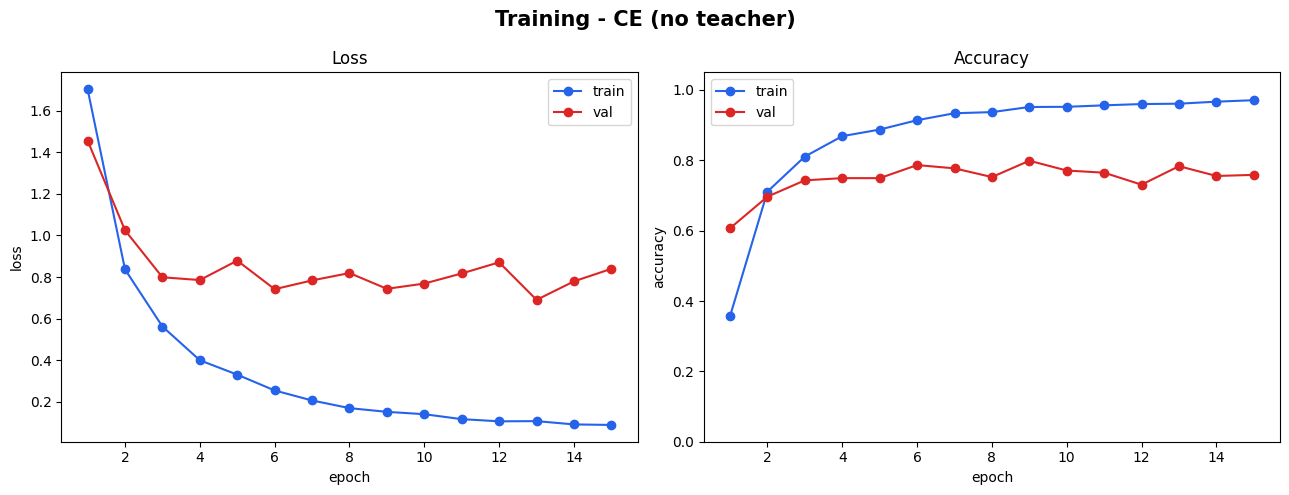

In [15]:
plot_training_results(hist_student_ce, task_name="CE (no teacher)")

## Held-out student evaluation

The trained student is evaluated on the common 20-class test set, producing accuracy and prediction data for subsequent error analysis.

In [16]:
acc_student_ce, preds_student_ce, labels_student_ce = test_model(student_ce, test_loader, device)

Test Accuracy: 0.8064


## Class-wise error analysis

The confusion matrix reveals class-specific error patterns and complements aggregate student accuracy.

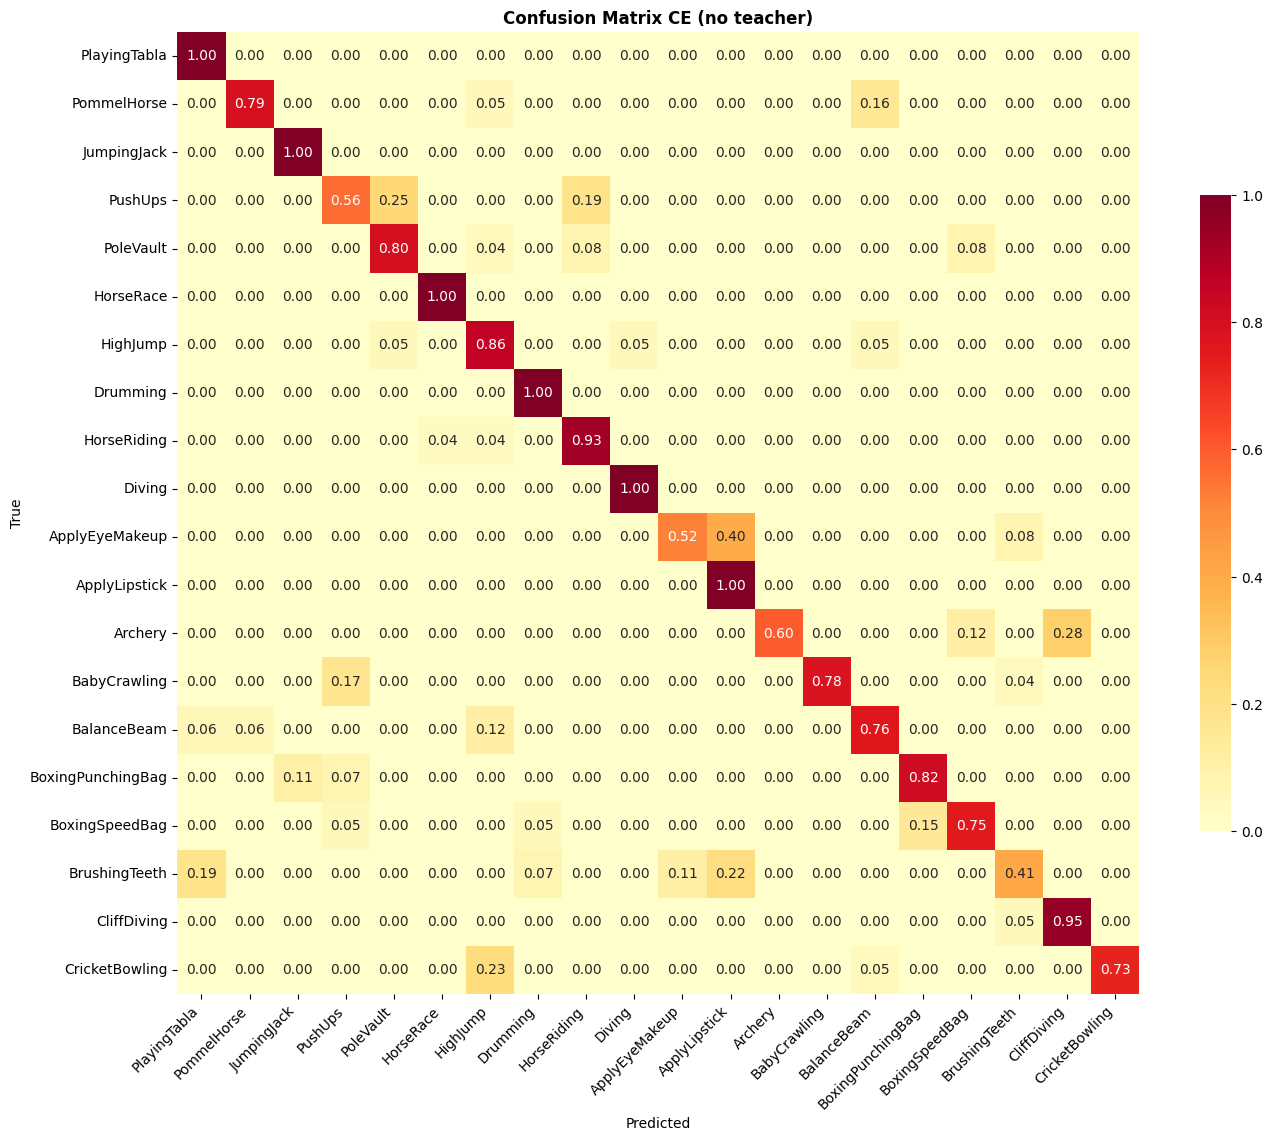

In [17]:
plot_confusion_matrix(labels_student_ce, preds_student_ce, num_classes=len(ALL_CLASSES_LIST), classes_list=ALL_CLASSES_LIST, name="CE (no teacher)")

## Student-result registration

Test accuracy and parameter count are added to the experimental registry, enabling direct comparison of compression effectiveness across training objectives.

In [18]:
params_student_ce = sum(p.numel() for p in student_ce.parameters())
RESULTS.append({"mode": "CE (no teacher)", "test_acc": acc_student_ce, "params_M": params_student_ce / 1e6})

## **CE + KD**

## Student instantiation: logit distillation

A fresh student is instantiated for the knowledge-distillation condition, ensuring that comparisons are not influenced by prior optimisation.

In [19]:
student_kd = MobileNetV3SmallLSTMStudent(num_classes=len(ALL_CLASSES_LIST)).to(device)

## Logit-based knowledge distillation

The student combines cross-entropy with a softened-logit distillation loss relative to the teacher. Temperature controls the smoothness of class probabilities, and the loss weights balance label fitting against teacher imitation.

In [20]:
set_seed(cfg.SEED)
student_kd, hist_student_kd = train_student(student_kd, teacher, train_loader, val_loader, device,
                                  mode="kd", T=cfg.KD_T, ce_weight=cfg.KD_CE_WEIGHT,
                                  distill_weight=cfg.KD_DISTILL_WEIGHT,
                                  epochs=cfg.KD_EPOCHS, lr=cfg.KD_LR)

[    kd] epoch 01/15 | Train Acc: 0.3427 | Val Acc: 0.6285
[    kd] epoch 02/15 | Train Acc: 0.6755 | Val Acc: 0.7059
[    kd] epoch 03/15 | Train Acc: 0.7851 | Val Acc: 0.7709
[    kd] epoch 04/15 | Train Acc: 0.8445 | Val Acc: 0.7709
[    kd] epoch 05/15 | Train Acc: 0.8852 | Val Acc: 0.7895
[    kd] epoch 06/15 | Train Acc: 0.8884 | Val Acc: 0.7616
[    kd] epoch 07/15 | Train Acc: 0.9238 | Val Acc: 0.8080
[    kd] epoch 08/15 | Train Acc: 0.9411 | Val Acc: 0.7833
[    kd] epoch 09/15 | Train Acc: 0.9426 | Val Acc: 0.8019
[    kd] epoch 10/15 | Train Acc: 0.9426 | Val Acc: 0.8111
[    kd] epoch 11/15 | Train Acc: 0.9598 | Val Acc: 0.8235
[    kd] epoch 12/15 | Train Acc: 0.9598 | Val Acc: 0.8173
[    kd] epoch 13/15 | Train Acc: 0.9645 | Val Acc: 0.7771
[    kd] epoch 14/15 | Train Acc: 0.9677 | Val Acc: 0.8111
[    kd] epoch 15/15 | Train Acc: 0.9760 | Val Acc: 0.8390
  best [kd] val 0.8390


## Optimisation diagnostics

The learning curves visualise training and validation dynamics for the current student objective, supporting convergence and overfitting assessment.

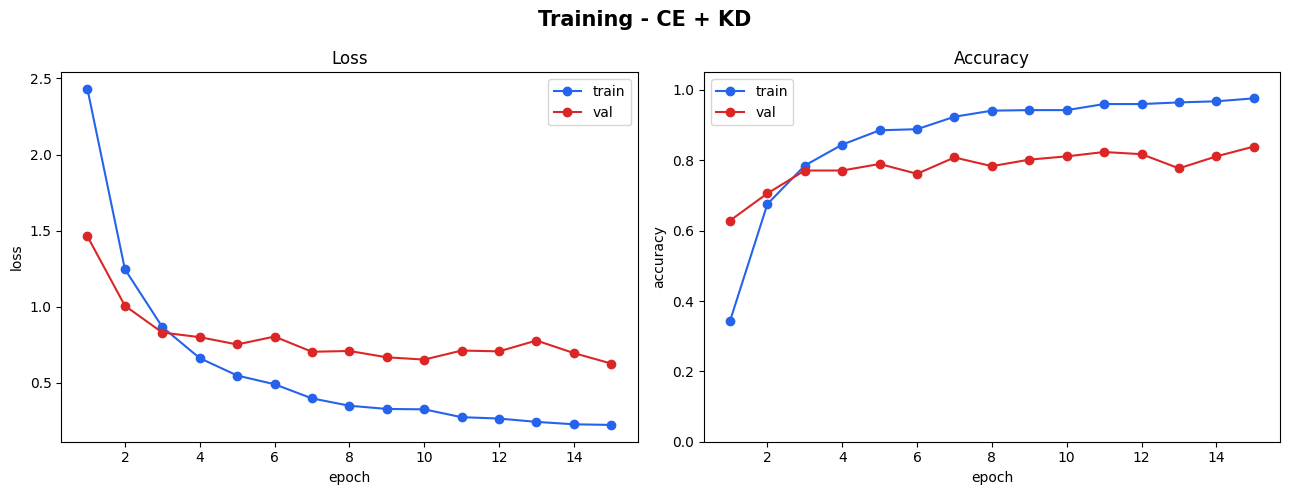

In [21]:
plot_training_results(hist_student_kd, task_name="CE + KD")

## Held-out student evaluation

The trained student is evaluated on the common 20-class test set, producing accuracy and prediction data for subsequent error analysis.

In [22]:
acc_student_kd, preds_student_kd, labels_student_kd = test_model(student_kd, test_loader, device)

Test Accuracy: 0.7973


## Class-wise error analysis

The confusion matrix reveals class-specific error patterns and complements aggregate student accuracy.

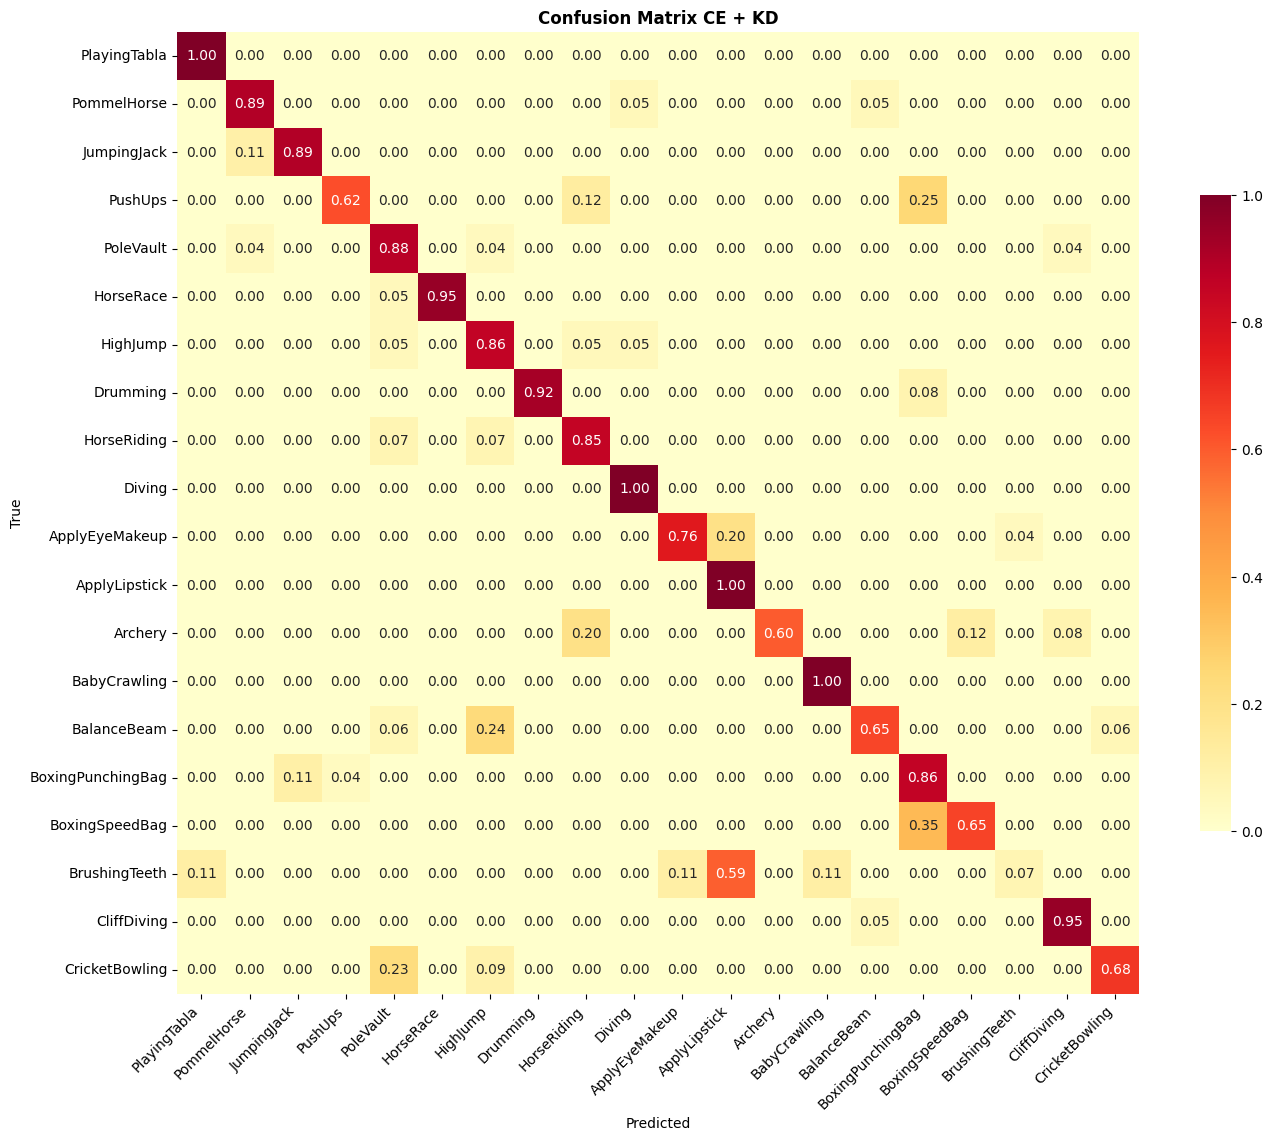

In [23]:
plot_confusion_matrix(labels_student_kd, preds_student_kd, num_classes=len(ALL_CLASSES_LIST), classes_list=ALL_CLASSES_LIST, name="CE + KD")

## Student-result registration

Test accuracy and parameter count are added to the experimental registry, enabling direct comparison of compression effectiveness across training objectives.

In [ ]:
params_student_kd = sum(p.numel() for p in student_kd.parameters())
RESULTS.append({"mode": "CE + KD", "test_acc": acc_student_kd, "params_M": params_student_kd / 1e6})

## **CE + Cosine**

## Student instantiation: cosine feature alignment

A new student is created for the condition that aligns its temporal representation with the teacher through cosine distance.

In [25]:
student_cos = MobileNetV3SmallLSTMStudent(num_classes=len(ALL_CLASSES_LIST)).to(device)

## Cosine alignment of latent states

The student is trained with supervised loss and a cosine-distance objective that aligns its 256-dimensional LSTM state with the teacher representation.

In [26]:
set_seed(cfg.SEED)
student_cos, hist_student_cos = train_student(student_cos, teacher, train_loader, val_loader, device,
                                  mode="cosine", T=cfg.KD_T, ce_weight=cfg.KD_CE_WEIGHT,
                                  distill_weight=cfg.KD_DISTILL_WEIGHT,
                                  epochs=cfg.KD_EPOCHS, lr=cfg.KD_LR)

[cosine] epoch 01/15 | Train Acc: 0.3396 | Val Acc: 0.6254
[cosine] epoch 02/15 | Train Acc: 0.6927 | Val Acc: 0.7461
[cosine] epoch 03/15 | Train Acc: 0.7934 | Val Acc: 0.7895
[cosine] epoch 04/15 | Train Acc: 0.8414 | Val Acc: 0.7152
[cosine] epoch 05/15 | Train Acc: 0.8878 | Val Acc: 0.7833
[cosine] epoch 06/15 | Train Acc: 0.9014 | Val Acc: 0.7833
[cosine] epoch 07/15 | Train Acc: 0.9233 | Val Acc: 0.7802
[cosine] epoch 08/15 | Train Acc: 0.9442 | Val Acc: 0.7771
[cosine] epoch 09/15 | Train Acc: 0.9468 | Val Acc: 0.8142
[cosine] epoch 10/15 | Train Acc: 0.9531 | Val Acc: 0.8173
[cosine] epoch 11/15 | Train Acc: 0.9531 | Val Acc: 0.7802
[cosine] epoch 12/15 | Train Acc: 0.9593 | Val Acc: 0.8111
[cosine] epoch 13/15 | Train Acc: 0.9609 | Val Acc: 0.7802
[cosine] epoch 14/15 | Train Acc: 0.9598 | Val Acc: 0.7554
[cosine] epoch 15/15 | Train Acc: 0.9671 | Val Acc: 0.7678
  best [cosine] val 0.8173


## Optimisation diagnostics

The learning curves visualise training and validation dynamics for the current student objective, supporting convergence and overfitting assessment.

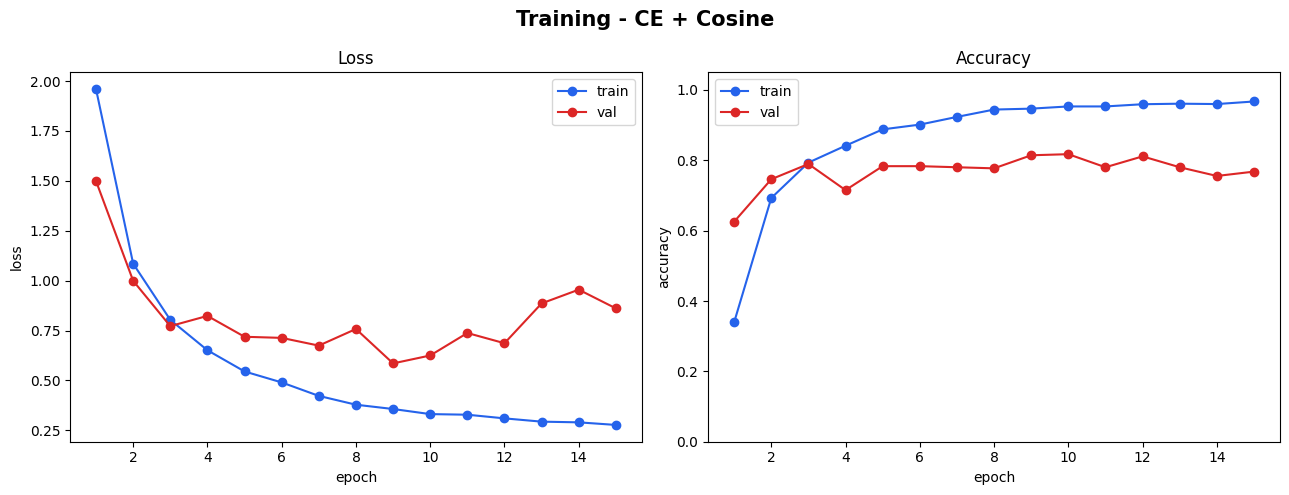

In [27]:
plot_training_results(hist_student_cos, task_name="CE + Cosine")

## Held-out student evaluation

The trained student is evaluated on the common 20-class test set, producing accuracy and prediction data for subsequent error analysis.

In [28]:
acc_student_cos, preds_student_cos, labels_student_cos = test_model(student_cos, test_loader, device)

Test Accuracy: 0.8269


## Class-wise error analysis

The confusion matrix reveals class-specific error patterns and complements aggregate student accuracy.

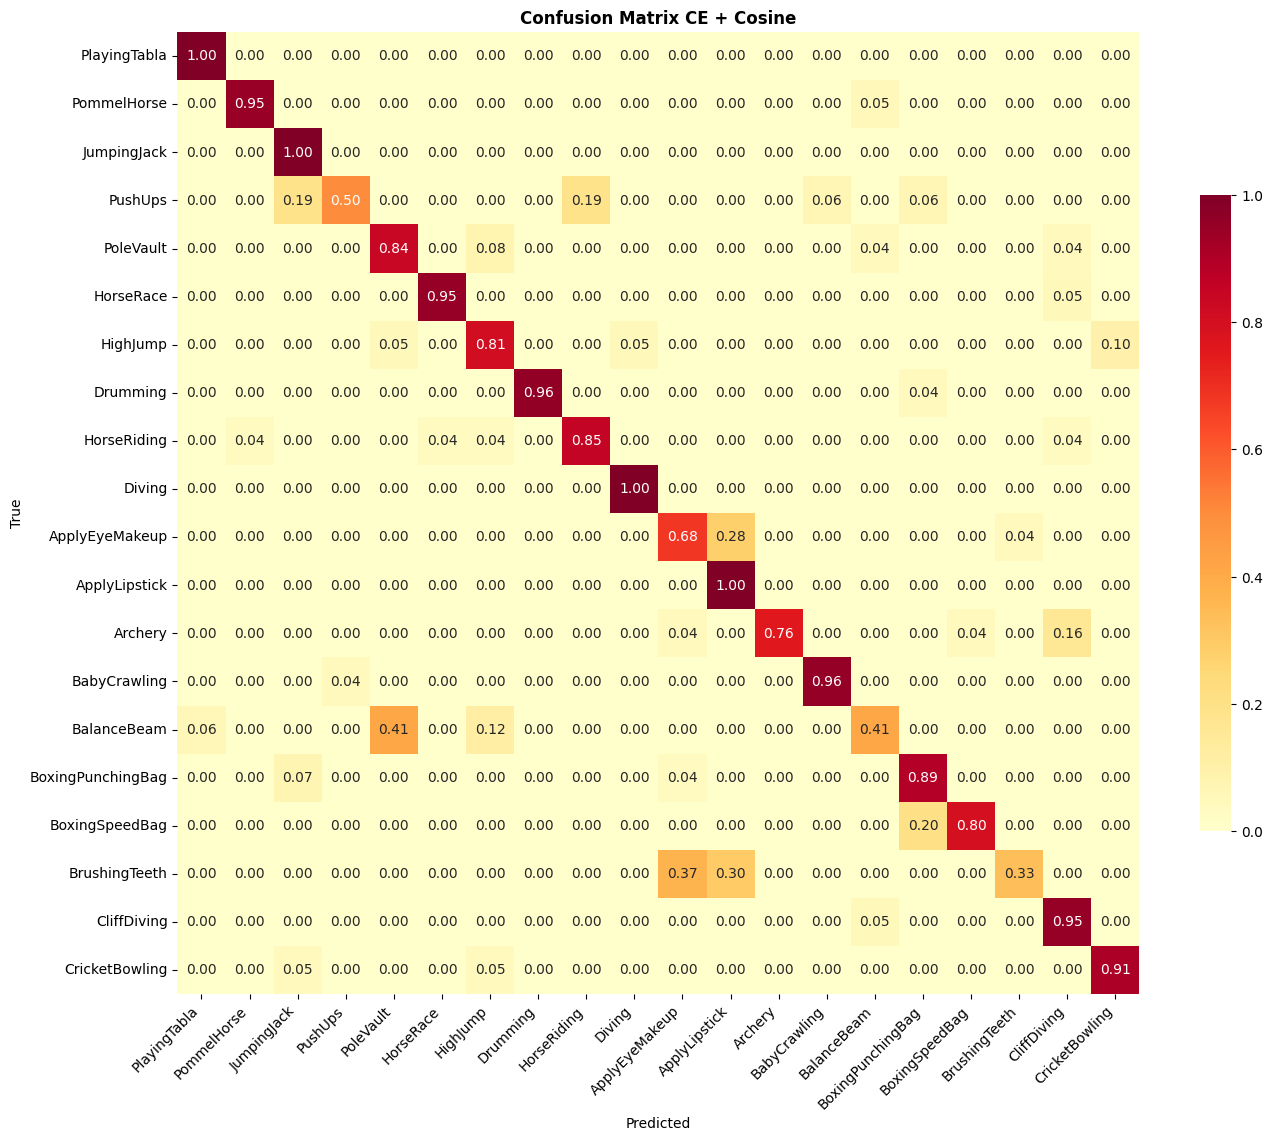

In [29]:
plot_confusion_matrix(labels_student_cos, preds_student_cos, num_classes=len(ALL_CLASSES_LIST), classes_list=ALL_CLASSES_LIST, name="CE + Cosine")

## Student-result registration

Test accuracy and parameter count are added to the experimental registry, enabling direct comparison of compression effectiveness across training objectives.

In [30]:
params_student_cos = sum(p.numel() for p in student_cos.parameters())
RESULTS.append({"mode": "CE + Cosine", "test_acc": acc_student_cos, "params_M": params_student_cos / 1e6})

## **CE + MSE (regressor)**

## Student instantiation: MSE feature alignment

A new student is instantiated for the condition that transfers the teacherâ€™s latent temporal representation using mean-squared error.

In [31]:
student_mse = MobileNetV3SmallLSTMStudent(num_classes=len(ALL_CLASSES_LIST)).to(device)

## MSE alignment of latent states

This condition uses mean-squared error to transfer the teacherâ€™s 256-dimensional temporal representation in addition to supervised classification loss.

In [32]:
set_seed(cfg.SEED)
student_mse, hist_student_mse = train_student(student_mse, teacher, train_loader, val_loader, device,
                                  mode="mse", T=cfg.KD_T, ce_weight=cfg.KD_CE_WEIGHT,
                                  distill_weight=cfg.KD_DISTILL_WEIGHT,
                                  epochs=cfg.KD_EPOCHS, lr=cfg.KD_LR)

[   mse] epoch 01/15 | Train Acc: 0.3495 | Val Acc: 0.6285
[   mse] epoch 02/15 | Train Acc: 0.6609 | Val Acc: 0.6873
[   mse] epoch 03/15 | Train Acc: 0.7877 | Val Acc: 0.6966
[   mse] epoch 04/15 | Train Acc: 0.8576 | Val Acc: 0.7183
[   mse] epoch 05/15 | Train Acc: 0.8894 | Val Acc: 0.7616
[   mse] epoch 06/15 | Train Acc: 0.9134 | Val Acc: 0.7740
[   mse] epoch 07/15 | Train Acc: 0.9280 | Val Acc: 0.7214
[   mse] epoch 08/15 | Train Acc: 0.9452 | Val Acc: 0.7647
[   mse] epoch 09/15 | Train Acc: 0.9536 | Val Acc: 0.7399
[   mse] epoch 10/15 | Train Acc: 0.9593 | Val Acc: 0.7647
[   mse] epoch 11/15 | Train Acc: 0.9468 | Val Acc: 0.8080
[   mse] epoch 12/15 | Train Acc: 0.9577 | Val Acc: 0.7957
[   mse] epoch 13/15 | Train Acc: 0.9697 | Val Acc: 0.7740
[   mse] epoch 14/15 | Train Acc: 0.9781 | Val Acc: 0.7740
[   mse] epoch 15/15 | Train Acc: 0.9713 | Val Acc: 0.7988
  best [mse] val 0.8080


## Optimisation diagnostics

The learning curves visualise training and validation dynamics for the current student objective, supporting convergence and overfitting assessment.

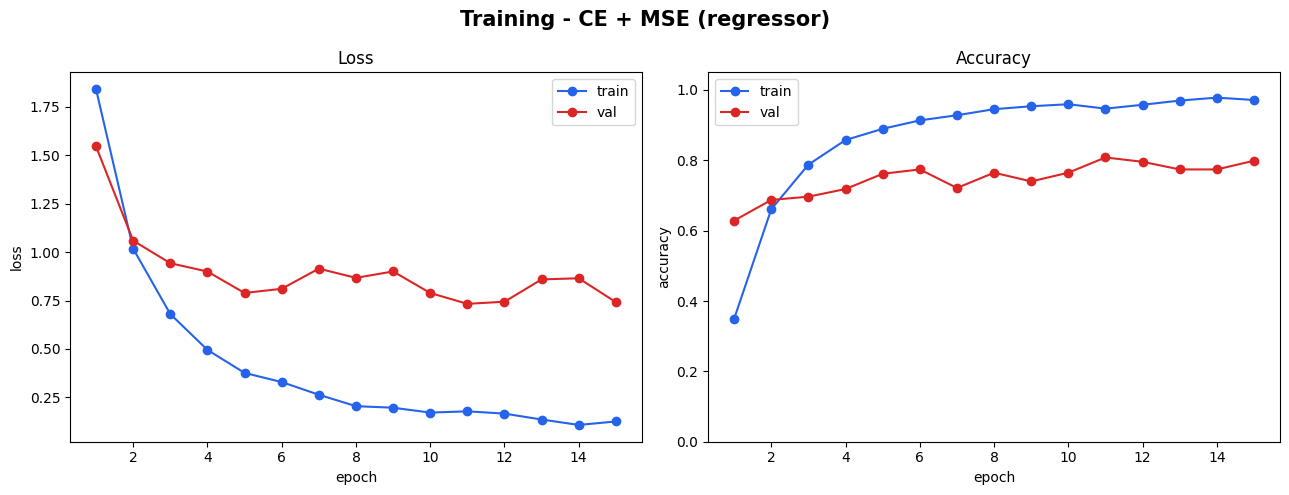

In [33]:
plot_training_results(hist_student_mse, task_name="CE + MSE (regressor)")

## Held-out student evaluation

The trained student is evaluated on the common 20-class test set, producing accuracy and prediction data for subsequent error analysis.

In [34]:
acc_student_mse, preds_student_mse, labels_student_mse = test_model(student_mse, test_loader, device)

Test Accuracy: 0.7585


## Class-wise error analysis

The confusion matrix reveals class-specific error patterns and complements aggregate student accuracy.

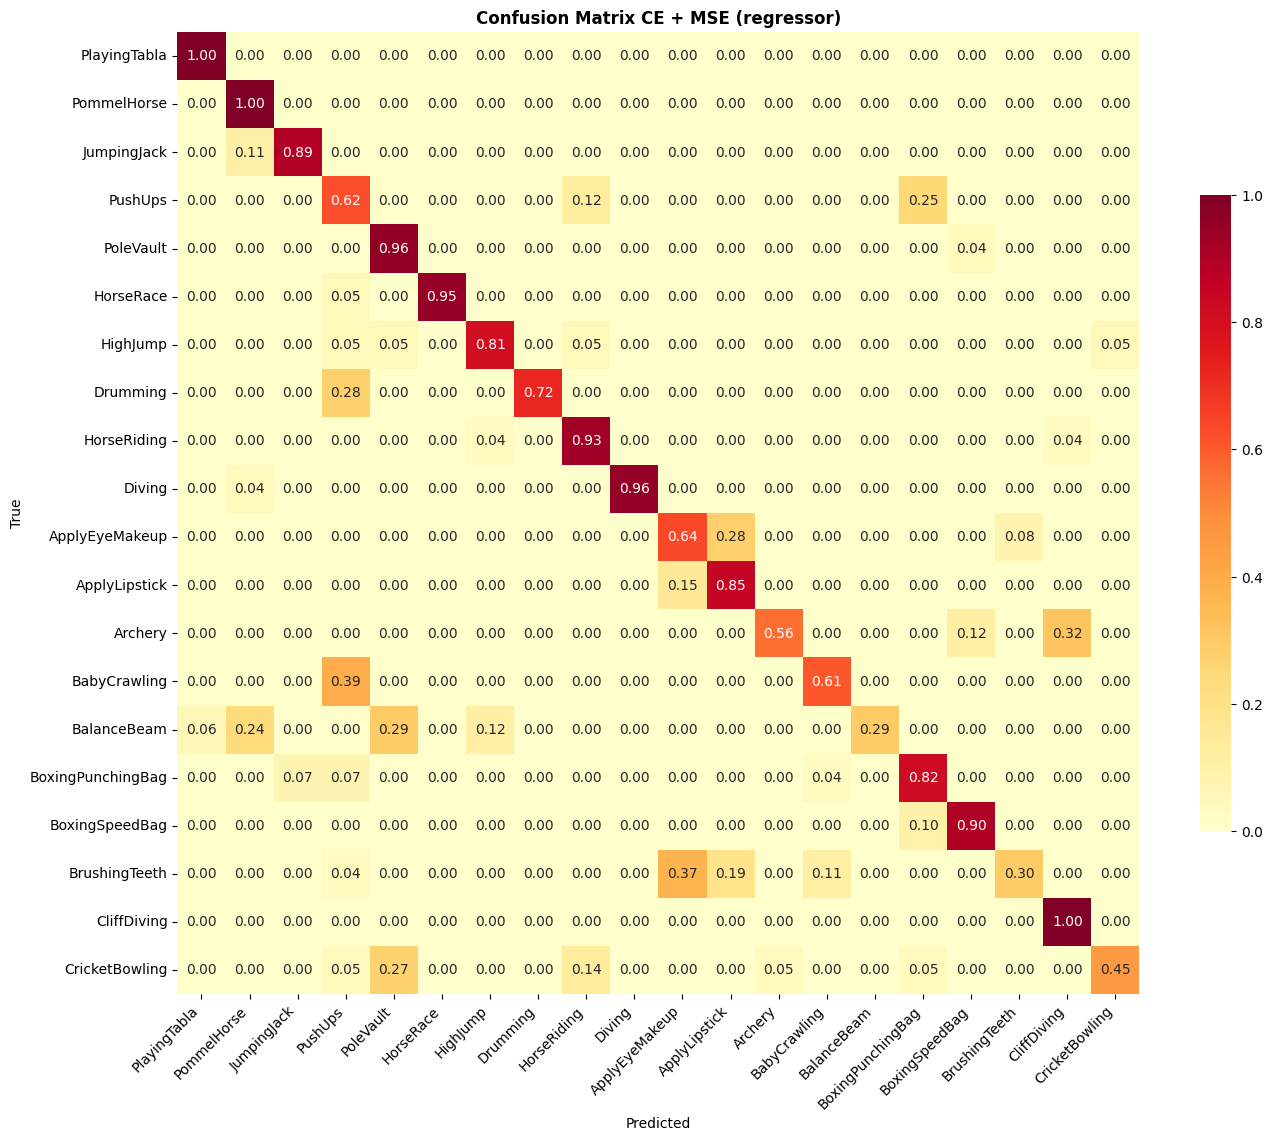

In [35]:
plot_confusion_matrix(labels_student_mse, preds_student_mse, num_classes=len(ALL_CLASSES_LIST), classes_list=ALL_CLASSES_LIST, name="CE + MSE (regressor)")

## Student-result registration

Test accuracy and parameter count are added to the experimental registry, enabling direct comparison of compression effectiveness across training objectives.

In [36]:
params_student_mse = sum(p.numel() for p in student_mse.parameters())
RESULTS.append({"mode": "CE + MSE (regressor)", "test_acc": acc_student_mse, "params_M": params_student_mse / 1e6})

## **Class-Prototypes Alignment**

## Student instantiation: MSE feature alignment

A new student is instantiated for the condition that transfers the teacherâ€™s latent temporal representation using mean-squared error.

In [15]:
student_proto = MobileNetV3SmallLSTMStudent(num_classes=len(ALL_CLASSES_LIST)).to(device)

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 62.5MB/s]


## Class-wise prototype alignment

The student is trained with a prototype-alignment objective that matches class-conditional clusters in representation space. The cluster count controls the granularity of intra-class structure transferred from the teacher.

In [16]:
set_seed(cfg.SEED)
student_proto, hist_student_proto = train_student(
    student_proto, 
    teacher, 
    train_loader, 
    val_loader, 
    device,
    mode="proto_align", 
    T=cfg.KD_T, 
    ce_weight=cfg.KD_CE_WEIGHT,
    distill_weight=cfg.KD_DISTILL_WEIGHT,
    proto_weight=0.5,       
    n_clusters=3,           # Number of KMeans clusters per class
    seed=cfg.SEED,          # Ensures reproducible KMeans clustering
    epochs=cfg.KD_EPOCHS, 
    lr=cfg.KD_LR
)

[proto_align] Extracting teacher feature prototypes using KMeans...
[proto_align] epoch 01/15 | Train Acc: 0.3589 | Val Acc: 0.6068
[proto_align] epoch 02/15 | Train Acc: 0.6870 | Val Acc: 0.7152
[proto_align] epoch 03/15 | Train Acc: 0.7929 | Val Acc: 0.7771
[proto_align] epoch 04/15 | Train Acc: 0.8638 | Val Acc: 0.8235
[proto_align] epoch 05/15 | Train Acc: 0.8910 | Val Acc: 0.7833
[proto_align] epoch 06/15 | Train Acc: 0.9374 | Val Acc: 0.7802
[proto_align] epoch 07/15 | Train Acc: 0.9421 | Val Acc: 0.8080
[proto_align] epoch 08/15 | Train Acc: 0.9551 | Val Acc: 0.8204
[proto_align] epoch 09/15 | Train Acc: 0.9687 | Val Acc: 0.7771
[proto_align] epoch 10/15 | Train Acc: 0.9692 | Val Acc: 0.8328
[proto_align] epoch 11/15 | Train Acc: 0.9739 | Val Acc: 0.8050
[proto_align] epoch 12/15 | Train Acc: 0.9692 | Val Acc: 0.8421
[proto_align] epoch 13/15 | Train Acc: 0.9849 | Val Acc: 0.8050
[proto_align] epoch 14/15 | Train Acc: 0.9791 | Val Acc: 0.8328
[proto_align] epoch 15/15 | Train Ac

## Optimisation diagnostics

The learning curves visualise training and validation dynamics for the current student objective, supporting convergence and overfitting assessment.

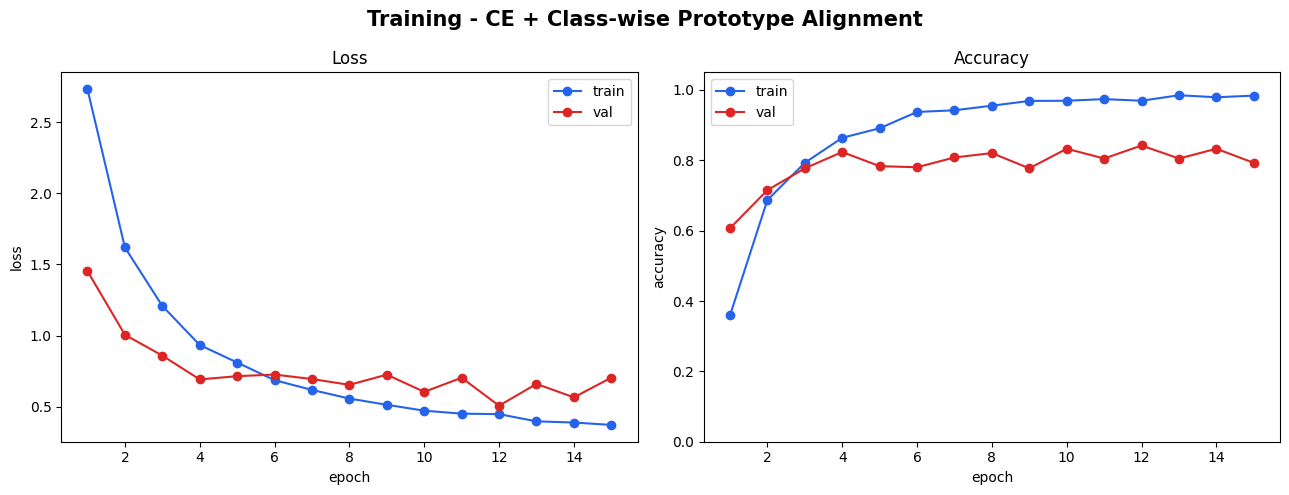

In [17]:
plot_training_results(hist_student_proto, task_name="CE + Class-wise Prototype Alignment")

## Held-out student evaluation

The trained student is evaluated on the common 20-class test set, producing accuracy and prediction data for subsequent error analysis.

In [18]:
acc_student_proto, preds_student_proto, labels_student_proto = test_model(student_proto, test_loader, device)

  test:   0%|          | 0/110 [00:00<?, ?it/s]/usr/local/lib/python3.13/dist-packages/torch/nn/modules/rnn.py:1169: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1479.)
  result = _VF.lstm(
                                                         

Test Accuracy: 0.8041


## Class-wise error analysis

The confusion matrix reveals class-specific error patterns and complements aggregate student accuracy.

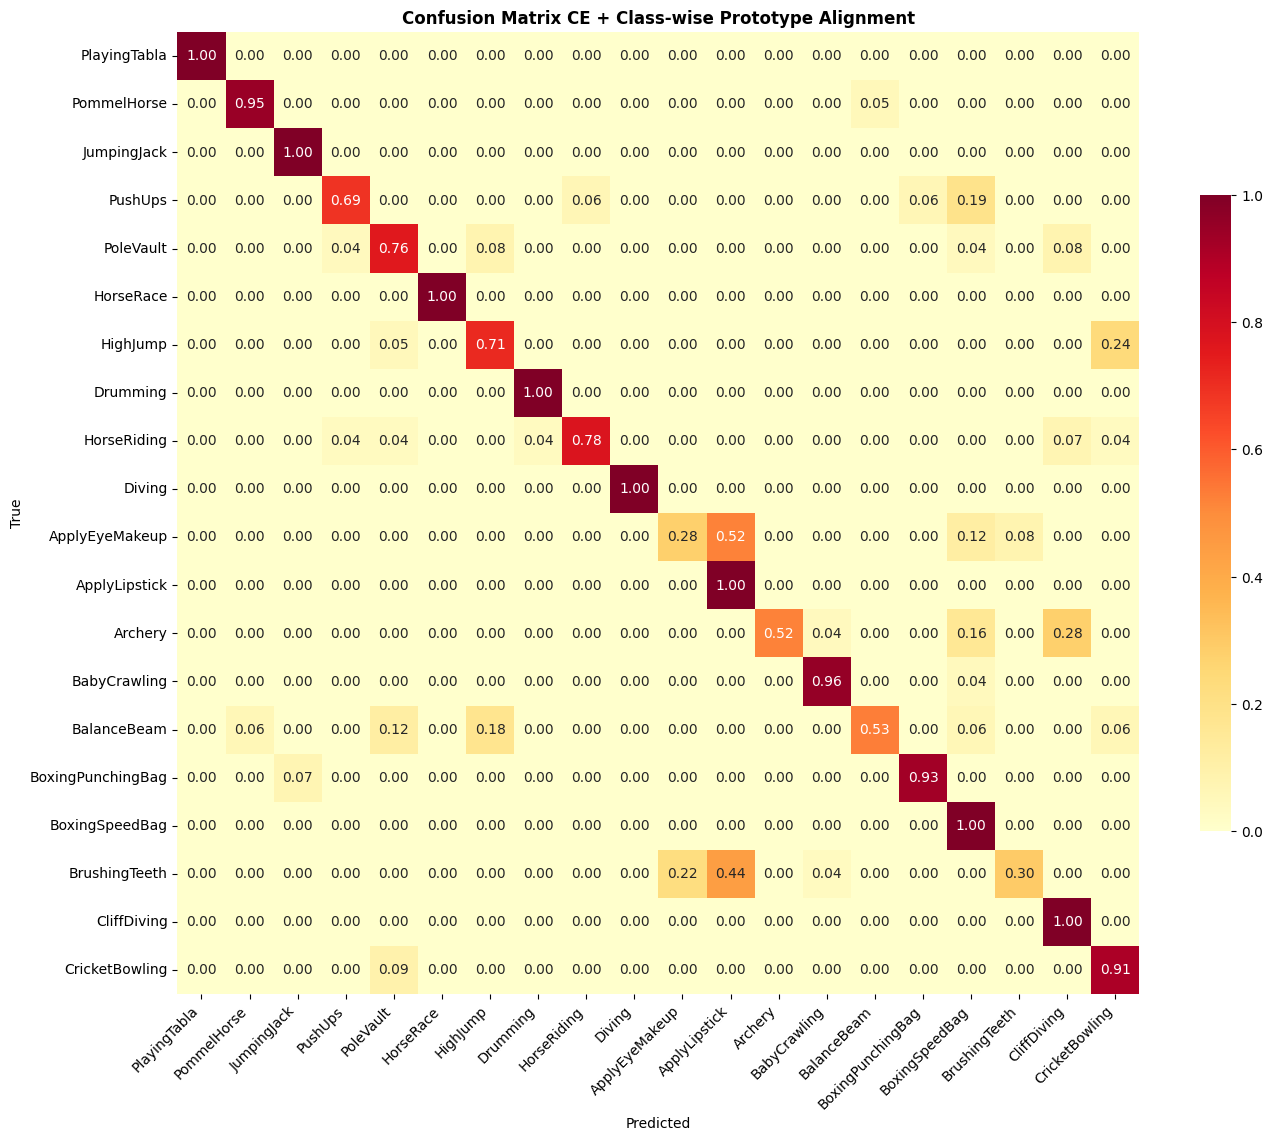

In [19]:
plot_confusion_matrix(labels_student_proto, preds_student_proto, num_classes=len(ALL_CLASSES_LIST), classes_list=ALL_CLASSES_LIST, name="CE + Class-wise Prototype Alignment")

## Student-result registration

Test accuracy and parameter count are added to the experimental registry, enabling direct comparison of compression effectiveness across training objectives.

In [20]:
params_student_proto = sum(p.numel() for p in student_proto.parameters())
RESULTS.append({"mode": "CE + Class-wise Prototype Alignment", "test_acc": acc_student_proto, "params_M": params_student_proto / 1e6})

## **Compare**

## Teacher student complexity comparison

The parameter count and accuracy of the teacher are reported alongside the approximate compression ratio achieved by the student architecture.

In [37]:
teacher_params = sum(p.numel() for p in teacher.parameters())
print(f"teacher : {teacher_acc:.4f}   ({teacher_params/1e6:.1f}M params)")
print(f"student is about {teacher_params / (RESULTS[0]['params_M'] * 1e6):.0f}x smaller than the teacher")

teacher : 0.8702   (25.9M params)
student is about 14x smaller than the teacher


## Comparative distillation analysis

The student variants are ranked by held-out accuracy in a consolidated results table.

In [38]:
results_df = pd.DataFrame(RESULTS).sort_values("test_acc", ascending=False).reset_index(drop=True)
results_df

,mode,test_acc,params_M
0,CE + Cosine,0.826879,1.786164
1,CE (no teacher),0.806378,1.786164
2,CE + KD,0.797267,1.786164
3,CE + MSE (regressor),0.758542,1.786164


## **Save**

The CE + KD student is saved as the student used in the domain-adaptation stage.

## Persistence of the selected student

The CE-plus-KD student checkpoint is saved for use in the subsequent domain-adaptation stage.

In [39]:
os.makedirs(cfg.CKPT_DIR, exist_ok=True)
torch.save(student_kd.state_dict(), f"{cfg.CKPT_DIR}/student.pt")
print(f"saved student -> {cfg.CKPT_DIR}/student.pt")

saved student -> /content/drive/MyDrive/apai/checkpoints/student.pt


## Persistence of distillation results

Teacher reference measures and student outcomes are written to structured JSON for reproducible reporting and downstream comparison.

In [40]:
os.makedirs(cfg.RESULTS_DIR, exist_ok=True)
payload = {"teacher_acc": teacher_acc, "teacher_params": teacher_params, "students": RESULTS}
with open(f"{cfg.RESULTS_DIR}/stage4_distillation.json", "w") as f:
    json.dump(payload, f, indent=2)
print(f"saved -> {cfg.RESULTS_DIR}/stage4_distillation.json")

saved -> /content/drive/MyDrive/apai/results/stage4_distillation.json
